In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://books.toscrape.com/"

# Send request to website
response = requests.get(url)

# Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# Store scraped data
data = []

# Extract book information
for book in soup.select("article.product_pod"):
    title = book.select_one("h3 a")["title"]
    price = book.select_one(".price_color").get_text(strip=True)

    data.append({
        "Title": title,
        "Price": price
    })

# Create DataFrame
df = pd.DataFrame(data)

# Display DataFrame as a table
display(df)

# Save DataFrame to CSV
df.to_csv("books.csv", index=False)

print("Saved", len(df), "records")

,Title,Price
0,A Light in the Attic,Â£51.77
1,Tipping the Velvet,Â£53.74
2,Soumission,Â£50.10
3,Sharp Objects,Â£47.82
4,Sapiens: A Brief History of Humankind,Â£54.23
5,The Requiem Red,Â£22.65
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60
9,The Black Maria,Â£52.15


Saved 20 records


In [5]:
df.info


<bound method DataFrame.info of                                                 Title    Price
0                                A Light in the Attic  Â£51.77
1                                  Tipping the Velvet  Â£53.74
2                                          Soumission  Â£50.10
3                                       Sharp Objects  Â£47.82
4               Sapiens: A Brief History of Humankind  Â£54.23
5                                     The Requiem Red  Â£22.65
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60
9                                     The Black Maria  Â£52.15
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99
11                              Shakespeare's Sonnets  Â£20.66
12                                        Set Me Free  Â£17.46
13  Scott Pilgrim's Precious Little Life (Scott Pi...  Â£52.29
14                     

### Cleaning|

In [6]:
import pandas as pd

df = pd.read_csv("books.csv")

print("Before cleaning:", df.shape)

Before cleaning: (20, 2)


In [10]:
# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Strip whitespace from title
df["Title"] = df["Title"].astype(str).str.strip()

# 3. Convert Price from string (e.g. "£51.77") to a proper float
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.extract(r"([\d.]+)")   # pulls out just the numeric part
    .astype(float)
)

# 4. Check for missing values
print("\nMissing values per column:\n", df.isnull().sum())

# 5. Drop any rows where Price couldn't be parsed
df = df.dropna(subset=["Price"])

print("\nAfter cleaning:", df.shape)

df.to_csv("books_cleaned.csv", index=False)
print("Saved cleaned data to books_cleaned.csv")


Missing values per column:
 Title    0
Price    0
dtype: int64

After cleaning: (20, 2)
Saved cleaned data to books_cleaned.csv


### Processing

In [11]:
import pandas as pd

df = pd.read_csv("books_cleaned.csv")

# 1. Price bucket - groups books into price ranges
df["Price_Bucket"] = pd.cut(
    df["Price"],
    bins=[0, 15, 30, 45, 60, 1000],
    labels=["<£15", "£15-30", "£30-45", "£45-60", "£60+"]
)

# 2. Title length features
df["Title_Length"] = df["Title"].str.len()
df["Title_Word_Count"] = df["Title"].str.split().str.len()

# 3. Simple price tier label (useful for grouping in the mining step)
def price_tier(p):
    if p < 20:
        return "Budget"
    elif p < 40:
        return "Mid-range"
    else:
        return "Premium"

df["Price_Tier"] = df["Price"].apply(price_tier)

df.to_csv("books_processed.csv", index=False)
print("Saved processed data to books_processed.csv")
print(df.head())

Saved processed data to books_processed.csv
                                   Title  Price Price_Bucket  Title_Length  \
0                   A Light in the Attic  51.77       £45-60            20   
1                     Tipping the Velvet  53.74       £45-60            18   
2                             Soumission  50.10       £45-60            10   
3                          Sharp Objects  47.82       £45-60            13   
4  Sapiens: A Brief History of Humankind  54.23       £45-60            37   

   Title_Word_Count Price_Tier  
0                 5    Premium  
1                 3    Premium  
2                 1    Premium  
3                 2    Premium  
4                 6    Premium  


# Mining

In [12]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("books_processed.csv")

In [13]:
# 1. Correlation between numeric features
numeric_cols = ["Price", "Title_Length", "Title_Word_Count"]
corr = df[numeric_cols].corr()
print("Correlation matrix:\n", corr.round(2), "\n")

Correlation matrix:
                   Price  Title_Length  Title_Word_Count
Price              1.00         -0.13             -0.17
Title_Length      -0.13          1.00              0.97
Title_Word_Count  -0.17          0.97              1.00 



In [14]:
# 2. Group statistics by price tier
tier_stats = df.groupby("Price_Tier").agg(
    avg_price=("Price", "mean"),
    avg_title_length=("Title_Length", "mean"),
    count=("Title", "count"),
)
print("Stats by price tier:\n", tier_stats, "\n")

Stats by price tier:
             avg_price  avg_title_length  count
Price_Tier                                    
Budget      16.460000         48.000000      3
Mid-range   27.962857         37.428571      7
Premium     51.585000         30.100000     10 



In [15]:
# 3. Group statistics by price bucket
bucket_stats = df.groupby("Price_Bucket", observed=True).agg(
    avg_price=("Price", "mean"),
    count=("Title", "count"),
)
print("Stats by price bucket:\n", bucket_stats, "\n")

Stats by price bucket:
               avg_price  count
Price_Bucket                  
<£15          13.990000      1
£15-30        20.863333      6
£30-45        35.316667      3
£45-60        51.585000     10 



### Visualization

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("books_mined.csv")

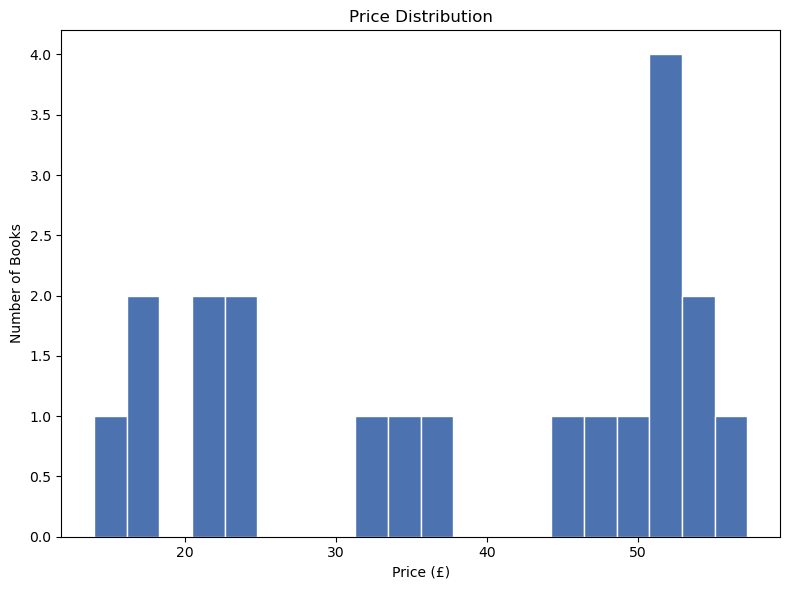

Saved viz1_price_distribution.png


In [26]:
plt.figure(figsize=(8, 6))
plt.hist(df["Price"], bins=20, color="#4C72B0", edgecolor="white")
plt.title("Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("viz1_price_distribution.png", dpi=150)
plt.show()
print("Saved viz1_price_distribution.png")

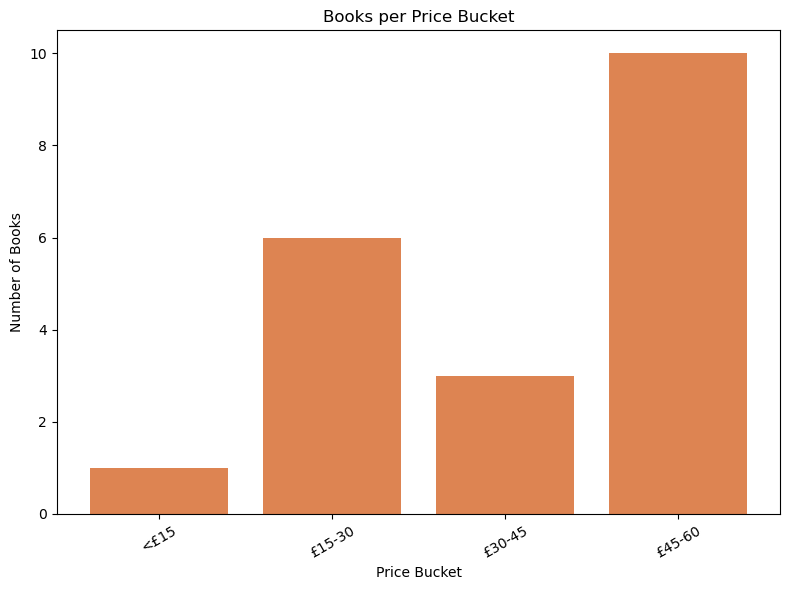

Saved viz2_price_bucket.png


In [27]:
bucket_order = ["<£15", "£15-30", "£30-45", "£45-60", "£60+"]
bucket_counts = df["Price_Bucket"].value_counts().reindex(bucket_order)

plt.figure(figsize=(8, 6))
plt.bar(bucket_counts.index.astype(str), bucket_counts.values, color="#DD8452")
plt.title("Books per Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Number of Books")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("viz2_price_bucket.png", dpi=150)
plt.show()
print("Saved viz2_price_bucket.png")

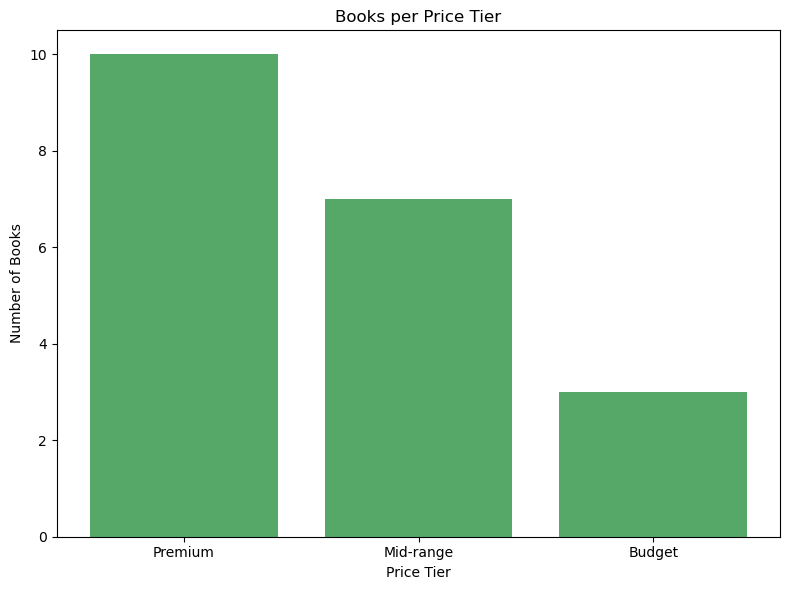

Saved viz3_price_tier.png


In [28]:
tier_counts = df["Price_Tier"].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(tier_counts.index, tier_counts.values, color="#55A868")
plt.title("Books per Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("viz3_price_tier.png", dpi=150)
plt.show()
print("Saved viz3_price_tier.png")

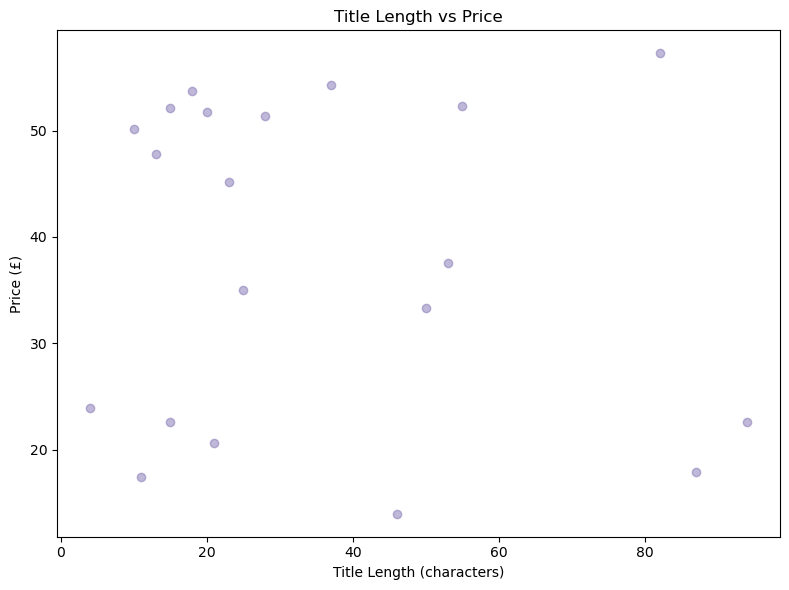

Saved viz4_title_vs_price.png


In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Title_Length"], df["Price"], alpha=0.5, color="#8172B2")
plt.title("Title Length vs Price")
plt.xlabel("Title Length (characters)")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.savefig("viz4_title_vs_price.png", dpi=150)
plt.show()
print("Saved viz4_title_vs_price.png")

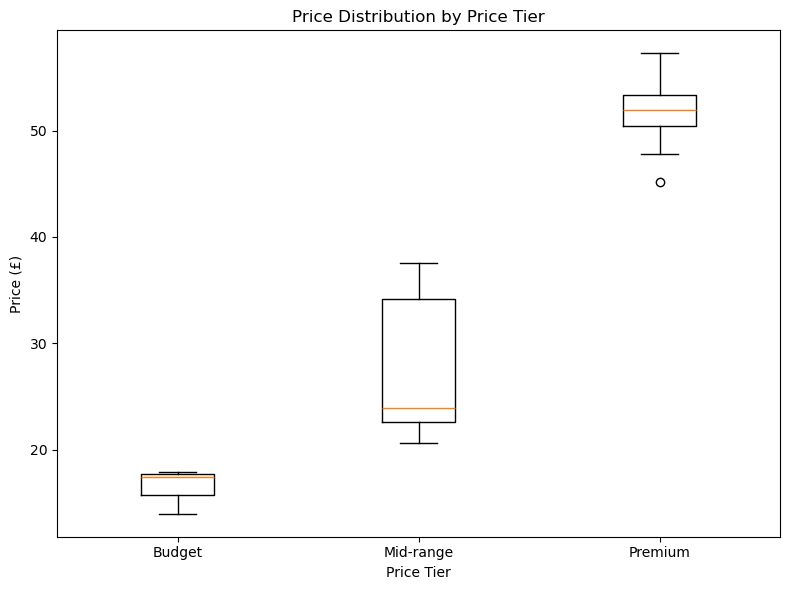

In [34]:
tier_order = ["Budget", "Mid-range", "Premium"]
data_by_tier = [df[df["Price_Tier"] == tier]["Price"] for tier in tier_order]

plt.figure(figsize=(8, 6))
box = plt.boxplot(data_by_tier)
plt.xticks(range(1, len(tier_order) + 1), tier_order)
plt.title("Price Distribution by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

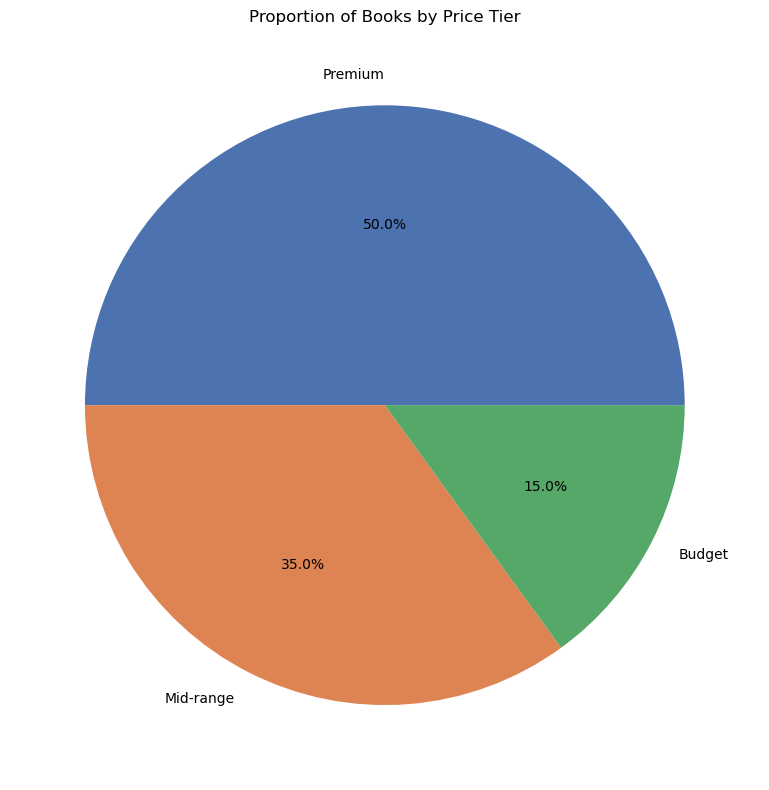

In [32]:
tier_counts = df["Price_Tier"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(tier_counts.values, labels=tier_counts.index, autopct="%1.1f%%",
        colors=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Proportion of Books by Price Tier")
plt.tight_layout()
plt.show()

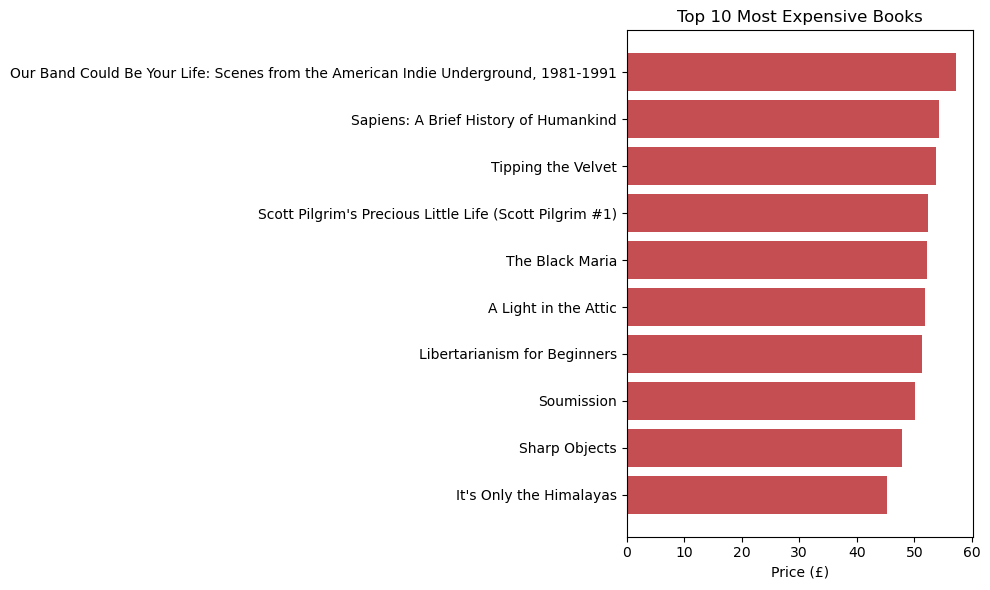

In [33]:
top10 = df.sort_values("Price", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["Title"], top10["Price"], color="#C44E52")
plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price (£)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

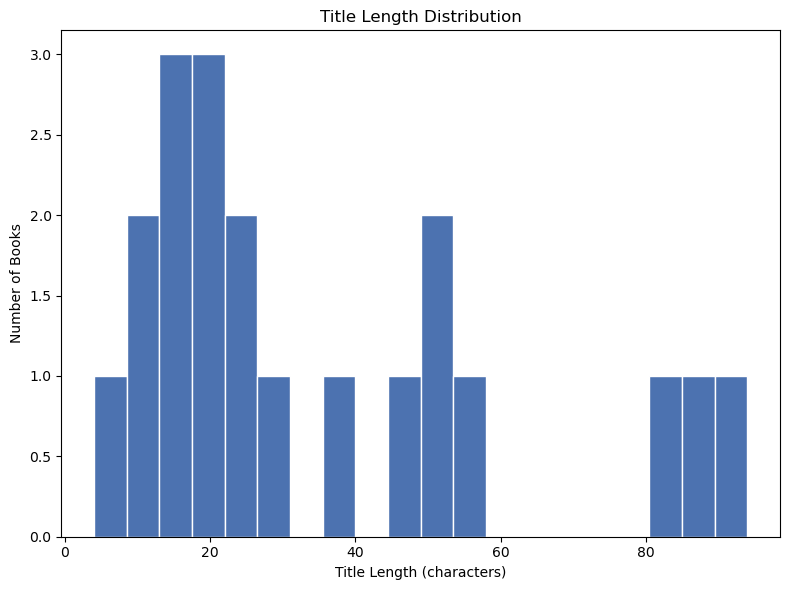

In [35]:
plt.figure(figsize=(8, 6))
plt.hist(df["Title_Length"], bins=20, color="#4C72B0", edgecolor="white")
plt.title("Title Length Distribution")
plt.xlabel("Title Length (characters)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

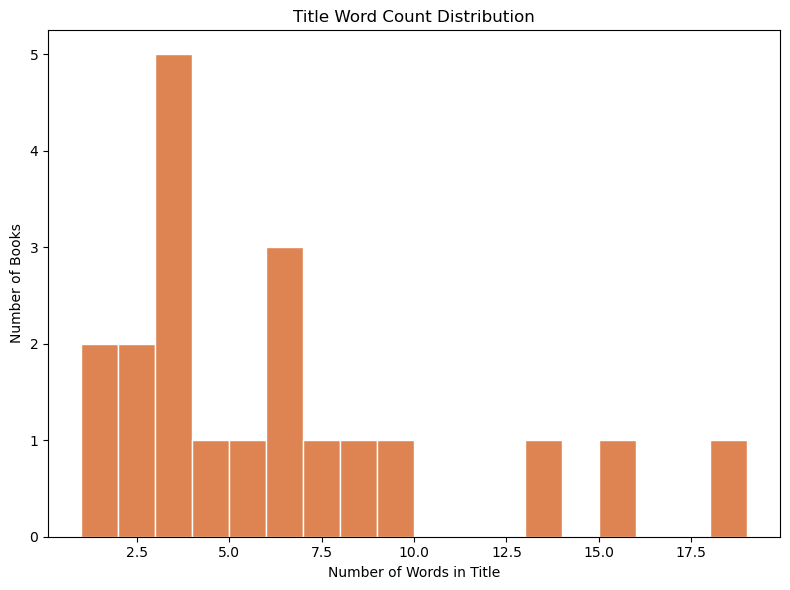

In [36]:
plt.figure(figsize=(8, 6))
plt.hist(df["Title_Word_Count"], bins=range(1, df["Title_Word_Count"].max() + 2),
         color="#DD8452", edgecolor="white")
plt.title("Title Word Count Distribution")
plt.xlabel("Number of Words in Title")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

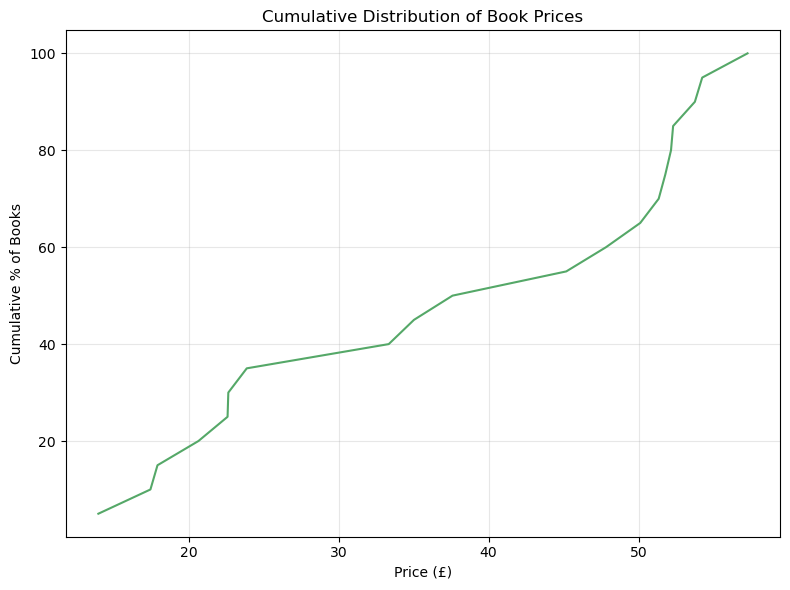

In [37]:
sorted_prices = df["Price"].sort_values()
cumulative_pct = (sorted_prices.rank(method="first") / len(sorted_prices)) * 100

plt.figure(figsize=(8, 6))
plt.plot(sorted_prices.values, cumulative_pct.values, color="#55A868")
plt.title("Cumulative Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Cumulative % of Books")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

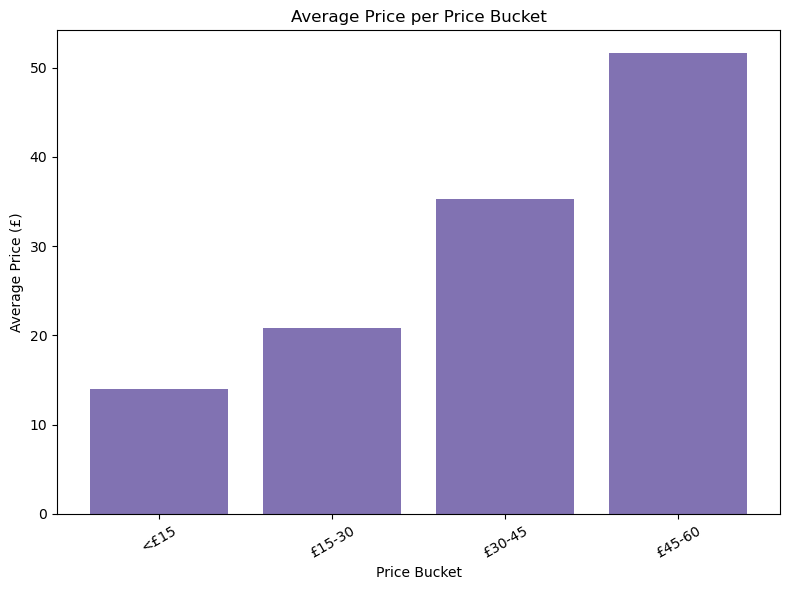

In [38]:
bucket_order = ["<£15", "£15-30", "£30-45", "£45-60", "£60+"]
avg_price = df.groupby("Price_Bucket", observed=True)["Price"].mean().reindex(bucket_order)

plt.figure(figsize=(8, 6))
plt.bar(avg_price.index.astype(str), avg_price.values, color="#8172B2")
plt.title("Average Price per Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

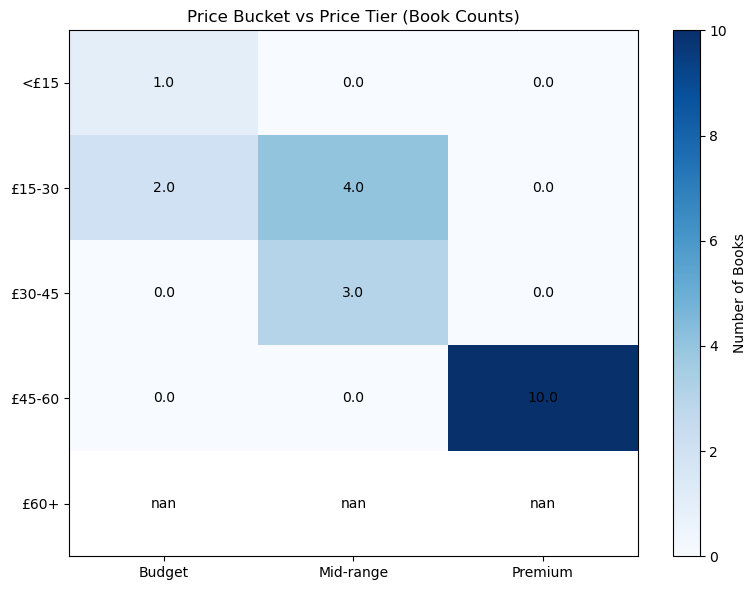

In [39]:
bucket_order = ["<£15", "£15-30", "£30-45", "£45-60", "£60+"]
tier_order = ["Budget", "Mid-range", "Premium"]

crosstab = pd.crosstab(df["Price_Bucket"], df["Price_Tier"])
crosstab = crosstab.reindex(index=bucket_order, columns=tier_order)

plt.figure(figsize=(8, 6))
plt.imshow(crosstab.values, cmap="Blues", aspect="auto")
plt.xticks(range(len(tier_order)), tier_order)
plt.yticks(range(len(bucket_order)), bucket_order)
plt.title("Price Bucket vs Price Tier (Book Counts)")
plt.colorbar(label="Number of Books")

# Annotate each cell with its count
for i in range(len(bucket_order)):
    for j in range(len(tier_order)):
        value = crosstab.values[i, j]
        plt.text(j, i, str(value), ha="center", va="center",
                  color="white" if value > crosstab.values.max() / 2 else "black")

plt.tight_layout()
plt.show()

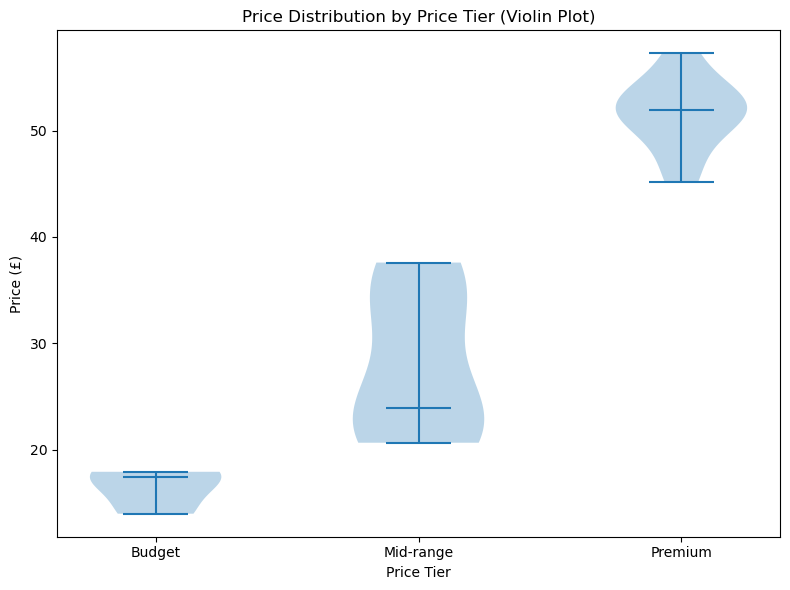

In [40]:
tier_order = ["Budget", "Mid-range", "Premium"]
data_by_tier = [df[df["Price_Tier"] == tier]["Price"] for tier in tier_order]

plt.figure(figsize=(8, 6))
plt.violinplot(data_by_tier, showmedians=True)
plt.xticks(range(1, len(tier_order) + 1), tier_order)
plt.title("Price Distribution by Price Tier (Violin Plot)")
plt.xlabel("Price Tier")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

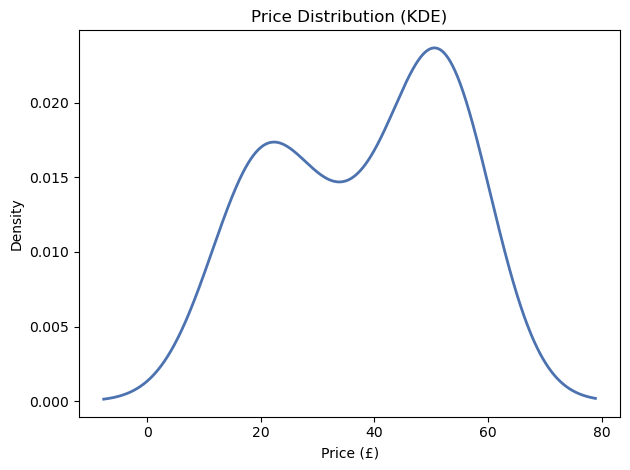

In [41]:
df["Price"].plot(kind="kde", color="#4C72B0", linewidth=2)
plt.title("Price Distribution (KDE)")
plt.xlabel("Price (£)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

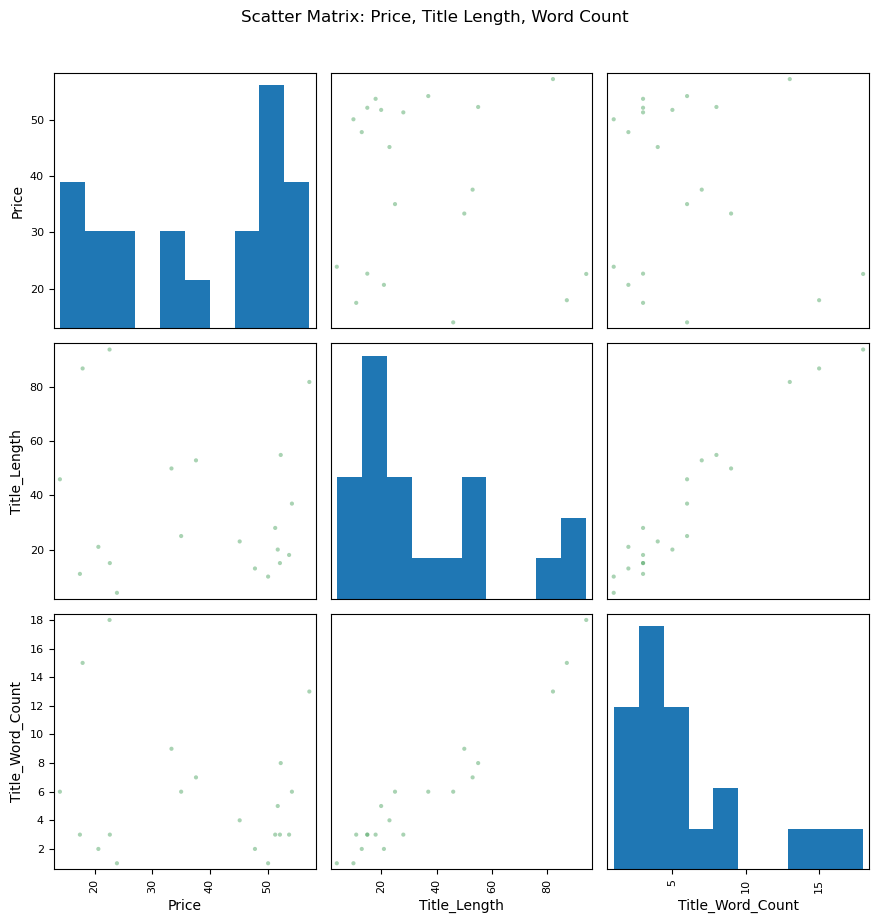

In [43]:
from pandas.plotting import scatter_matrix
cols = ["Price", "Title_Length", "Title_Word_Count"]
scatter_matrix(df[cols], figsize=(9, 9), diagonal="hist", color="#55A868", alpha=0.5)
plt.suptitle("Scatter Matrix: Price, Title Length, Word Count", y=1.02)
plt.tight_layout()
plt.show()

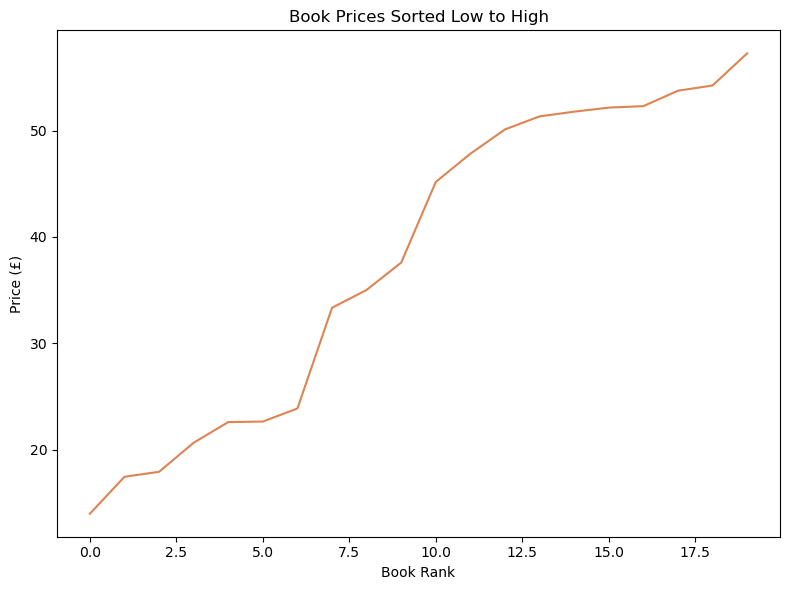

In [44]:
sorted_prices = df["Price"].sort_values().reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.plot(sorted_prices.index, sorted_prices.values, color="#DD8452")
plt.title("Book Prices Sorted Low to High")
plt.xlabel("Book Rank")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

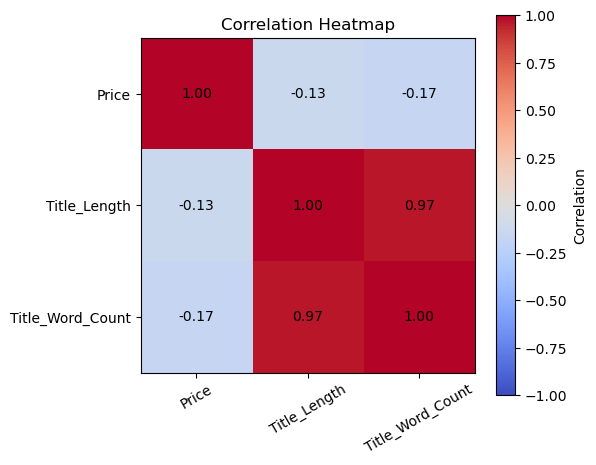

In [45]:
cols = ["Price", "Title_Length", "Title_Word_Count"]
corr = df[cols].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=30)
plt.yticks(range(len(cols)), cols)
plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap")

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

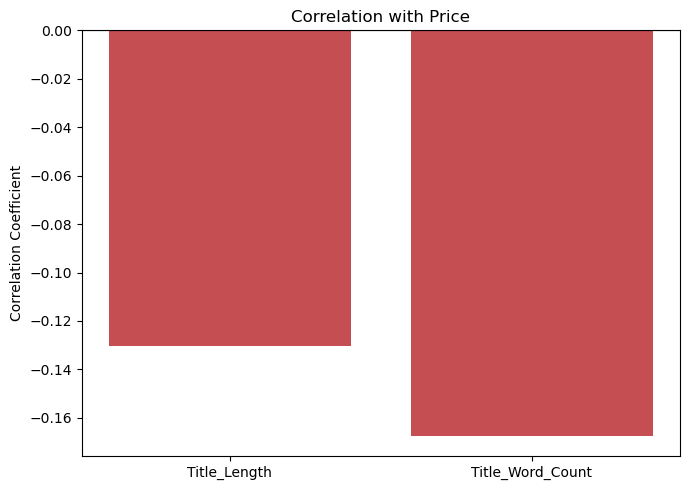

In [47]:
cols = ["Title_Length", "Title_Word_Count"]
correlations = df[cols].corrwith(df["Price"])

plt.figure(figsize=(7, 5))
colors = ["#55A868" if v >= 0 else "#C44E52" for v in correlations.values]
plt.bar(correlations.index, correlations.values, color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Correlation with Price")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show

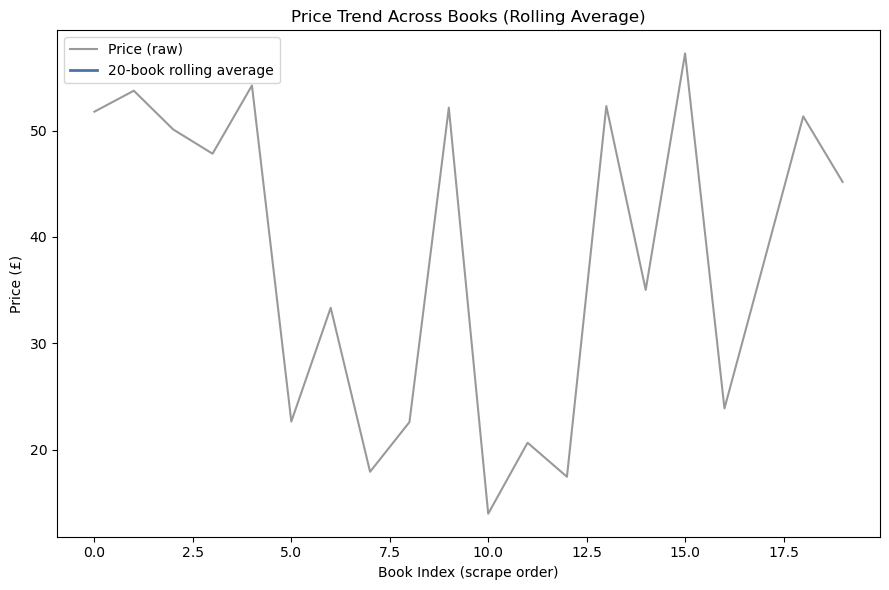

In [49]:
rolling_avg = df["Price"].rolling(window=20).mean()

plt.figure(figsize=(9, 6))
plt.plot(df.index, df["Price"], color="black", alpha=0.4, label="Price (raw)")
plt.plot(df.index, rolling_avg, color="#4C72B0", linewidth=2, label="20-book rolling average")
plt.title("Price Trend Across Books (Rolling Average)")
plt.xlabel("Book Index (scrape order)")
plt.ylabel("Price (£)")
plt.legend()
plt.tight_layout()
plt.show()